DETECTIING WHETHER A GIVEN MESSAGE IS SPAM OR NOT

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import nltk
from nltk.stem.porter import PorterStemmer
import pickle

In [4]:
df = pd.read_csv("spam.csv", encoding="latin-1")

In [5]:
print(df.shape)
df.sample(5)

(5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1571,ham,Near kalainar tv office.thenampet,NaN,NaN,NaN
424,ham,Send this to ur friends and receive something ...,NaN,NaN,NaN
1395,ham,Thats cool! I am a gentleman and will treat yo...,NaN,NaN,NaN
985,ham,Carlos says he'll be at mu in &lt;#&gt; minutes,NaN,NaN,NaN
5479,ham,Really do hope the work doesnt get stressful. ...,NaN,NaN,NaN


In [6]:
# for col in df.columns:
#     print(df[col], " :", df[col].isnull().value_counts())
dt = df.columns
print(dt)
for col in dt:
    print(col, ": " , df[col].isnull().value_counts())

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')
v1 :  v1
False    5572
Name: count, dtype: int64
v2 :  v2
False    5572
Name: count, dtype: int64
Unnamed: 2 :  Unnamed: 2
True     5522
False      50
Name: count, dtype: int64
Unnamed: 3 :  Unnamed: 3
True     5560
False      12
Name: count, dtype: int64
Unnamed: 4 :  Unnamed: 4
True     5566
False       6
Name: count, dtype: int64


In [7]:
df['status'] = df['v1']
df = df.drop(['v1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df.sample(3)

,v2,status
2022,U can WIN å£100 of Music Gift Vouchers every w...,spam
2624,S da..al r above &lt;#&gt;,ham
2581,Yup i'm elaborating on the safety aspects and ...,ham


In [8]:
print(df.duplicated().sum())
df = df.drop_duplicates(keep='first')
df.shape

403


(5169, 2)

In [9]:
df['status'].value_counts()

status
ham     4516
spam     653
Name: count, dtype: int64

In [10]:
from sklearn.preprocessing import LabelEncoder
encode = LabelEncoder()
print(df.head(3))
df['status'] = encode.fit_transform(df['status'])
print(df.head(3))


                                                  v2 status
0  Go until jurong point, crazy.. Available only ...    ham
1                      Ok lar... Joking wif u oni...    ham
2  Free entry in 2 a wkly comp to win FA Cup fina...   spam


                                                  v2  status
0  Go until jurong point, crazy.. Available only ...       0
1                      Ok lar... Joking wif u oni...       0
2  Free entry in 2 a wkly comp to win FA Cup fina...       1


WE CAN'T MARK HAM TO SPAM (IT'S OK TO CONSIDER SPAM AS HAM, BUT A HAM MESSAGE SHOULDN'T BE CONSIDERED AS SPAM)


In [11]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\somee\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [12]:
df.head(4)

,v2,status
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0


In [13]:
df['num_char'] = df['v2'].apply(lambda x : len(x))
df['num_word'] = df['v2'].apply(lambda x : len(nltk.word_tokenize(x)))

In [14]:
df.sample(5)

,v2,status,num_char,num_word
489,I think i've fixed it can you send a test mess...,0,50,13
4875,lyricalladie(21/F) is inviting you to be her f...,1,137,28
2992,So i'm doing a list of buyers.,0,30,9
3771,Does uncle timi help in clearing cars,0,37,7
5261,I absolutely LOVE South Park! I only recently ...,0,74,14


In [15]:
df[df['status'] == 1].describe()

,status,num_char,num_word
count,653.0,653.000000,653.000000
mean,1.0,137.891271,27.667688
std,0.0,30.137753,7.008418
min,1.0,13.000000,2.000000
25%,1.0,132.000000,25.000000
50%,1.0,149.000000,29.000000
75%,1.0,157.000000,32.000000
max,1.0,224.000000,46.000000


In [16]:
df[df['status'] == 0].describe()

,status,num_char,num_word
count,4516.0,4516.000000,4516.000000
mean,0.0,70.459256,17.123782
std,0.0,56.358207,13.493970
min,0.0,2.000000,1.000000
25%,0.0,34.000000,8.000000
50%,0.0,52.000000,13.000000
75%,0.0,90.000000,22.000000
max,0.0,910.000000,220.000000


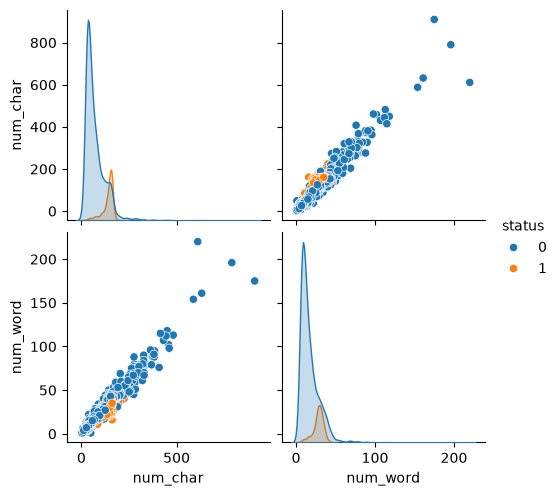

In [17]:
sns.pairplot(df, hue='status')

In [18]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\somee\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
ps = PorterStemmer()

In [20]:
from string import punctuation
from nltk.corpus import stopwords
def convert(text):
    text = text.lower()
    x = nltk.word_tokenize(text)

    #keep alpha nuberic characters only
    res = []
    for let in x:
        if let.isalnum():
            res.append(let)

    res2 = res[:]
    res.clear()
    for let in res2:
        if let not in punctuation and let not in stopwords.words('english'):
            res.append(let)


    res2 = res[:]
    res.clear()

    for let in res2:
        res.append(ps.stem(let))


    return " ".join(res)

def convert2(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))


    return " ".join(y)

In [ ]:
print(convert("Hey someeran !!! how re you... let's grab some drink and learn machine learning"))
convert2("Hey someeran !!! how re you... let's grab some drink and learn machine learning")

hey someeran 2bhai let grab drink learn machin learn


'hey someeran 2bhai let grab drink learn machin learn'

In [22]:
dt = df[['status', 'num_char', 'num_word']]
dt.corr()


,status,num_char,num_word
status,1.000000,0.384717,0.262912
num_char,0.384717,1.000000,0.965760
num_word,0.262912,0.965760,1.000000


In [23]:
df['text'] = df['v2'].apply(convert2)

In [24]:

df.head(5)

,v2,status,num_char,num_word,text
0,"Go until jurong point, crazy.. Available only ...",0,111,24,go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,0,29,8,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,37,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,0,49,13,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",0,61,15,nah think goe usf live around though


In [25]:
df['num_char'] = df['text'].apply(lambda x : len(x))

In [26]:
df.head(5)

,v2,status,num_char,num_word,text
0,"Go until jurong point, crazy.. Available only ...",0,76,24,go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,0,21,8,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,127,37,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,0,35,13,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",0,36,15,nah think goe usf live around though


In [27]:
df.drop(['num_word'], axis = 1)


,v2,status,num_char,text
0,"Go until jurong point, crazy.. Available only ...",0,76,go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,0,21,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,127,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,0,35,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",0,36,nah think goe usf live around though
...,...,...,...,...
5567,This is the 2nd time we have tried 2 contact u...,1,86,2nd time tri 2 contact u pound prize 2 claim e...
5568,Will Ì_ b going to esplanade fr home?,0,21,b go esplanad fr home
5569,"Pity, * was in mood for that. So...any other s...",0,17,piti mood suggest
5570,The guy did some bitching but I acted like i'd...,0,65,guy bitch act like interest buy someth els nex...


In [28]:
df['status'].value_counts()

status
0    4516
1     653
Name: count, dtype: int64

<Axes: >

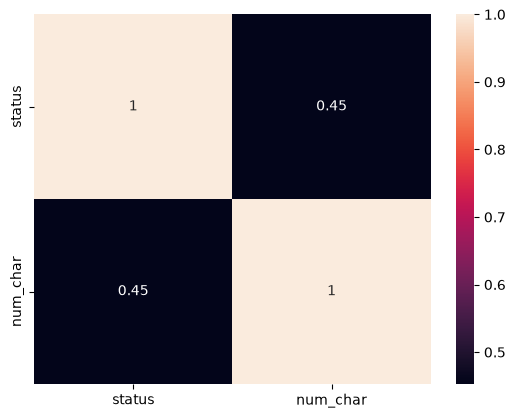

In [29]:
sns.heatmap(df[['status', 'num_char']].corr(), annot=True)

In [30]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfdf = TfidfVectorizer(max_features=3000)

dat = "hey its me someeran how you are doing"
dat = dat.split()
x = cv.fit_transform(dat)
x.toarray()



array([[0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0]])

In [31]:
df.shape

(5169, 5)

FINDING THE MOST OCCURING WORD IN SPAM

In [32]:
data = df[df['status'] == 1]['text'].tolist()
print("done")

done


In [33]:
spam = []
for sent in data:
  for word in sent.split():
    spam.append(word)

print(len(spam))


9939


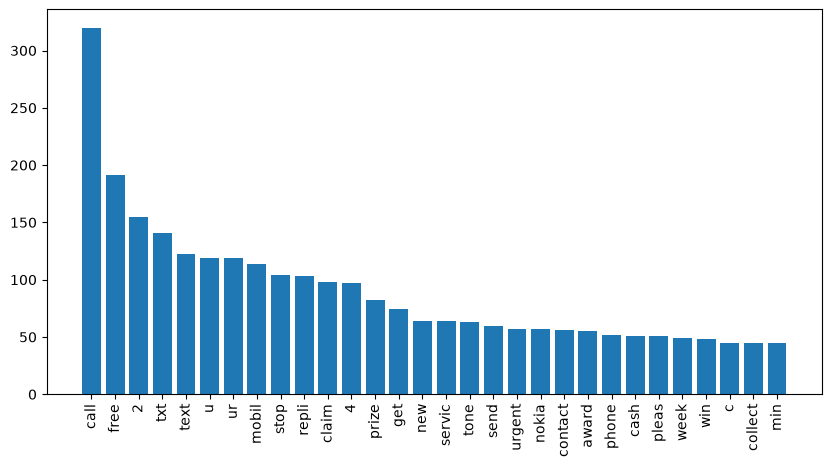

In [34]:

from collections import Counter
data = Counter(spam).most_common(30)
data = pd.DataFrame(data, columns=['word', 'count'])
plt.figure(figsize=(10, 5))
plt.bar(data['word'], data['count'])
plt.xticks(rotation=90)
plt.show()

35404


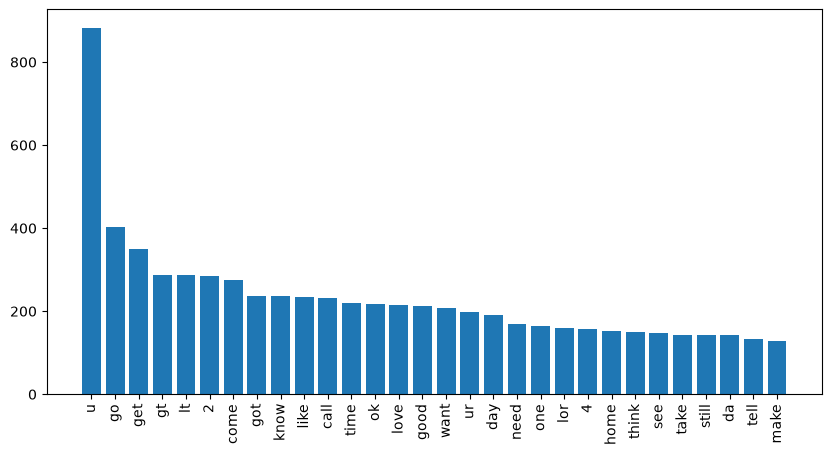

In [35]:
ham = []
for sent in df[df['status'] == 0]['text']:
  for word in sent.split():
    ham.append(word)

print(len(ham))

data = Counter(ham).most_common(30)
data = pd.DataFrame(data, columns=['word', 'count'])
plt.figure(figsize=(10, 5))
plt.bar(data['word'], data['count'])
plt.xticks(rotation=90)
plt.show()

**BUILDING MODEL**


In [36]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfdf = TfidfVectorizer(max_features=3000)

x = cv.fit_transform(df['text']).toarray()
pickle.dump(cv, open('vectorizer.pkl', 'wb'))
x1 = tfdf.fit_transform(df['text']).toarray()
y = df['status'].values
print(x, x1, y)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]] [0 0 1 ... 0 0 0]


In [37]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y, test_size = 0.2, random_state = 42)
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier


mnb = MultinomialNB()
gnb = GaussianNB()
bnb = BernoulliNB()


mnb.fit(x_train, y_train)
gnb.fit(x_train, y_train)
bnb.fit(x_train, y_train)

dict = {"mnb" : mnb, "gnb" : gnb, "bnb" : bnb}


**HERE PRECISION MATTERS MORE- WE CAN'T SAY A HAM MESSAGE IS A SPAM**

In [38]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score
for key in dict:
  print(key, " ")
  y_pred = dict.get(key).predict(x_test)
  # print(classification_report(y_test, y_pred))
  print(confusion_matrix(y_test, y_pred))
  print(accuracy_score(y_test, y_pred))

mnb  
[[872  17]
 [ 10 135]]
0.9738878143133463
gnb  
[[772 117]
 [ 19 126]]
0.8684719535783365
bnb  
[[885   4]
 [ 31 114]]
0.9661508704061895


In [39]:
mnb = MultinomialNB()
gnb = GaussianNB()
bnb = BernoulliNB()


mnb.fit(x1_train, y1_train)
gnb.fit(x1_train, y1_train)
bnb.fit(x1_train, y1_train)

dict = {"mnb" : mnb, "gnb" : gnb, "bnb" : bnb}


from sklearn.metrics import classification_report, accuracy_score
for key in dict:
  print(key, " ")
  y_pred = dict.get(key).predict(x1_test)
  #print(classification_report(y1_test, y_pred))
  print(confusion_matrix(y1_test, y_pred))
  print(accuracy_score(y1_test, y_pred))

mnb  
[[888   1]
 [ 27 118]]
0.9729206963249516
gnb  
[[771 118]
 [ 24 121]]
0.8626692456479691
bnb  
[[884   5]
 [ 23 122]]
0.9729206963249516


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)


clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'GBDT':gbdt,
    'xgb':xgb
}



In [41]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision
accuracy_scores = []
precision_scores = []



for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, x_train,y_train,x_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9323017408123792
Precision -  0.7737226277372263
For  KN
Accuracy -  0.9042553191489362
Precision -  1.0
For  NB
Accuracy -  0.9738878143133463
Precision -  0.8881578947368421
For  DT
Accuracy -  0.9235976789168279
Precision -  0.9230769230769231
For  LR
Accuracy -  0.9709864603481625
Precision -  0.9457364341085271


d:\Documents\Projects\sms_spam_detection\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Documents\Projects\sms_spam_detection\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  RF
Accuracy -  0.9671179883945842
Precision -  1.0
For  AdaBoost
Accuracy -  0.90715667311412
Precision -  0.8656716417910447
For  GBDT
Accuracy -  0.9342359767891683
Precision -  0.8811881188118812
For  xgb
Accuracy -  0.9700193423597679
Precision -  0.9453125


In [42]:
# def train_classifier(clf,X_train,y_train,X_test,y_test):
#     clf.fit(X_train,y_train)
#     y_pred = clf.predict(X_test)
#     accuracy = accuracy_score(y_test,y_pred)
#     precision = precision_score(y_test,y_pred)

#     return accuracy,precision
# accuracy_scores = []
# precision_scores = []



# for name,clf in clfs.items():

#     current_accuracy,current_precision = train_classifier(clf, x1_train,y1_train,x1_test,y1_test)

#     print("For ",name)
#     print("Accuracy - ",current_accuracy)
#     print("Precision - ",current_precision)

#     accuracy_scores.append(current_accuracy)
#     precision_scores.append(current_precision)

**RANDOM FOREST IS OUTPERFORMING WITH PRECISOIN 100% COMPARED TO OTHER ALGORITHMS **

In [43]:
def do_train(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return clf, accuracy,precision

rfc = RandomForestClassifier(n_estimators=50, random_state=2)
rfc, current_accuracy,current_precision = do_train(rfc, x_train,y_train,x_test,y_test)
print("Accuracy - ",current_accuracy)
print("Precision - ",current_precision)

Accuracy -  0.9671179883945842
Precision -  1.0


In [44]:
y_pred = rfc.predict(x_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       1.00      0.77      0.87       145

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034

[[889   0]
 [ 34 111]]


In [45]:
x_test

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1034, 6708))

In [46]:
print(len(y_train))
print("zeroes : ", len(y_train) - np.count_nonzero(y_train), "ones : ", np.count_nonzero(y_train))


4135
zeroes :  3627 ones :  508


In [47]:

print(rfc.n_features_in_)

6708


TASK TO DO WHEN WE GET A SMS TO VERIFY
1. DO STEMING AND CHANGE THE FORMAT OF TEXT
2. VECTORIZED THAT USING TFIDF
3. PREDICT USING MODEL

REQUIREMENT:
1. MODEL
2. PORTSCANNER
3. VECTORIZER

In [48]:
import pickle
pickle.dump(rfc, open('model.pkl', 'wb'))
pickle.dump(ps, open('stemmer.pkl', 'wb'))


EXTRACTING RANDOM SAMPLE DATA FOR TESTING OF MODEL (5-5 SPAM AND HAM )

In [49]:
import random
random_data = {}
# for i in range(5):
#   random_data.append(random.choice(df[df['status'] == 0]['text']))

# for i in range(5):
#   random_data.append(random.choice(df[df['status'] == 1]['text']))
data = df[df['status'] == 1]['v2'].sample(5)
for i in data:
  random_data[i] = 1

data = df[df['status'] == 0]['v2'].sample(5)
for i in data:
  random_data[i] = 0

print(random_data)

{'Congratulations! Thanks to a good friend U have WON the å£2,000 Xmas prize. 2 claim is easy, just call 08718726971 NOW! Only 10p per minute. BT-national-rate.': 1, 'You are being contacted by our dating service by someone you know! To find out who it is, call from a land line 09050000878. PoBox45W2TG150P': 1, 'Dont forget you can place as many FREE Requests with 1stchoice.co.uk as you wish. For more Information call 08707808226.': 1, "I want some cock! My hubby's away, I need a real man 2 satisfy me. Txt WIFE to 89938 for no strings action. (Txt STOP 2 end, txt rec å£1.50ea. OTBox 731 LA1 7WS. )": 1, 'Dear Voucher Holder, 2 claim this weeks offer, at your PC go to http://www.e-tlp.co.uk/expressoffer Ts&Cs apply.2 stop texts txt STOP to 80062.': 1, "Why didn't u call on your lunch?": 0, "If you can make it any time tonight or whenever you can it's cool, just text me whenever you're around": 0, '* Am on my way': 0, 'My mobile number.pls sms ur mail id.convey regards to achan,amma.Rakhe

In [50]:
# from sklearn.tree import plot_tree
# rfc.feature_importances_
# chosen_tree = rfc.estimators_[0]


# plt.figure(figsize=(15, 8))
# plot_tree(
#     chosen_tree,
#     filled=True,
#     rounded=True,
#     fontsize=10
# )
# plt.title("Visual Structure of Tree #0 in the Random Forest")
# plt.show()